# Exercises for Section 3.1 Estimates and estimators

This notebook contains the solutions to the exercises
from [Section 3.1 Estimates and estimators]()
in the **No Bullshit Guide to Statistics**.

### Notebooks setup

In [1]:
# Ensure required Python modules are installed
%pip install --quiet numpy scipy seaborn pandas ministats


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Figures setup
plt.clf()  # needed otherwise `sns.set_theme` doesn't work
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
)
%config InlineBackend.figure_format = "retina"

<Figure size 640x480 with 0 Axes>

In [4]:
# Simplified int and float __repr__
import numpy as np
np.set_printoptions(legacy='1.25')

In [5]:
# Pandas display options
pd.set_option("display.precision", 2)

In [6]:
# Download datasets/ directory if necessary
from ministats import ensure_datasets
ensure_datasets()

datasets/ directory already exists.


### Estimator functions defined in Section 3.1

In [7]:

# def var(sample):
#     xbar = mean(sample)
#     sumsqdevs = sum([(xi-xbar)**2 for xi in sample])
#     return sumsqdevs / (len(sample)-1)

# def std(sample):
#     s2 = var(sample)
#     return np.sqrt(s2)



## Exercises 1


### E3.1

Compute the sample mean from Batch 01 and Batch 04 of the kombucha dataset `datasets/kombucha.csv` .

In [9]:
# Load the kombucha dataset
kombucha = pd.read_csv("datasets/kombucha.csv")

# Select the volume measurements from Batch 04
ksample04 = kombucha[kombucha["batch"]==4]["volume"]

# Compute the mean volume in Batch 04
ksample04.mean()

1003.8335

### E3.2

Compute the sample variance from Batch 02 and Batch 08 of the kombucha dataset `datasets/kombucha.csv`.

In [11]:
# Load the kombucha dataset
kombucha = pd.read_csv("datasets/kombucha.csv")

# Select Batch 02 from the kombucha dataset
ksample02 = kombucha[kombucha["batch"]==2]["volume"]

# Compute its variance
ksample02.var()

124.31760105263139

In [13]:
# Select Batch 08 from the kombucha dataset
ksample08 = kombucha[kombucha["batch"]==8]["volume"]

# Compute its variance
ksample08.var()

169.99792205128236

### E3.3

Compute the difference between the means of the sleep `score`s 
for the doctors working in `rur`al and `urb`an locations
in the doctors dataset `datasets/doctors.csv`.

Hint: Use the code `doctors[doctors["loc"]=="rur"]` to select
the subset of the doctors working in a `rural` location.

In [14]:
import numpy as np

# Define the `dmeans` estimator function
def dmeans(xsample, ysample):
    dhat = np.mean(xsample) - np.mean(ysample)
    return dhat

In [16]:
# Load the doctors dataset
doctors = pd.read_csv("datasets/doctors.csv")

# Select doctors from "rur" location and get the `score` variable
scoresR = doctors[doctors["loc"]=="rur"]["score"]

# Select doctors from "urb" location and get the `score` variable
scoresU = doctors[doctors["loc"]=="urb"]["score"]

# Compute difference between mean scores
dmeans(scoresR, scoresU)

6.992885375494076

## Exercises 2


### E3.4

Generate $N=10000$ observations from the sampling distribution of the estimator `std` for samples of size $n=20$ from the population $K \sim \mathcal{N}(1000,10)$ .
Plot a histogram.

In [17]:
# Define the standard deviation estimator function
def std(sample):
    xbar = sum(sample) / len(sample)
    sumsqdevs = sum([(xi-xbar)**2 for xi in sample])
    return np.sqrt(sumsqdevs / (len(sample)-1))

# Create a computer model for the kombucha population
from scipy.stats import norm
muK = 1000
sigmaK = 10
rvK = norm(muK, sigmaK)

In [20]:
from ministats import gen_sampling_dist

# Set the random seed to a particular value to get a reproducible result
np.random.seed(42)

# Generate observations from the sampling distribution of `std`
kstds20 = gen_sampling_dist(rvK, estfunc=std, n=20, N=10000)
kstds20[0:5]

[9.60028421439027,
 9.680387092176915,
 8.208476944118853,
 11.120875642249183,
 6.908107201543384]

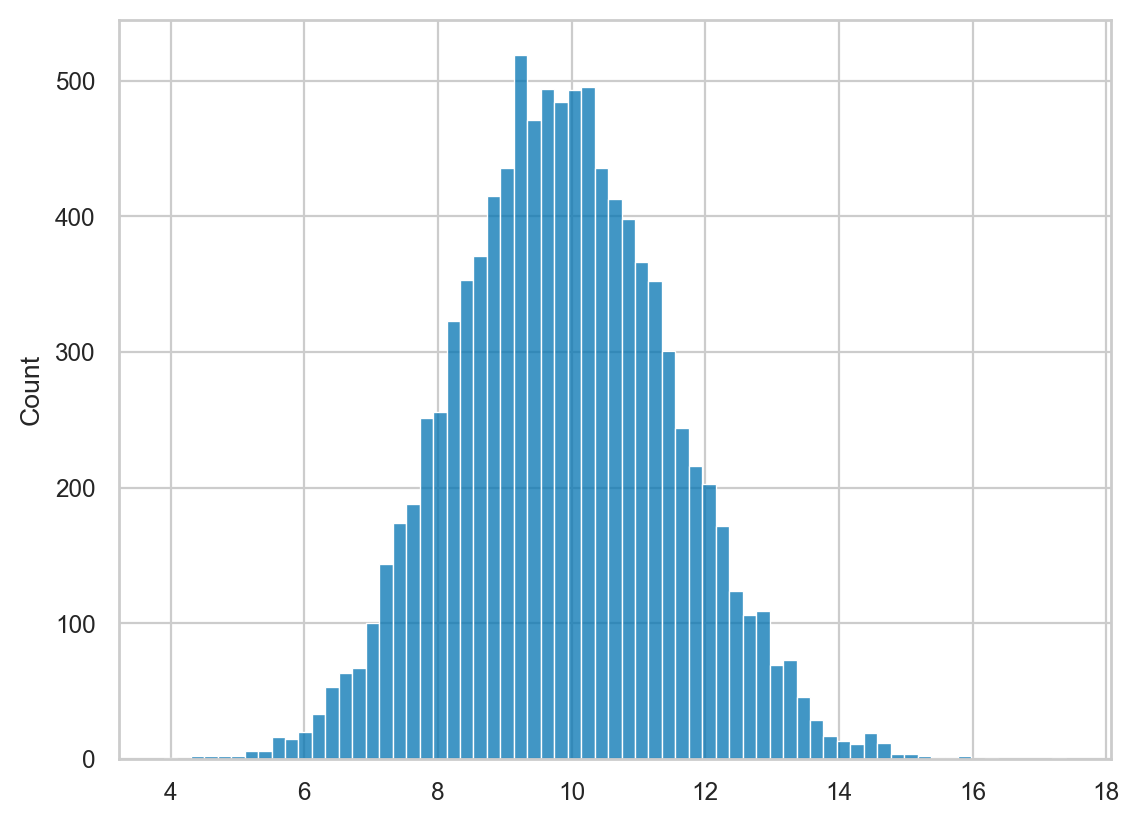

In [21]:
import seaborn as sns
# Plot histogram of the sampling distribution `kstds20`
sns.histplot(kstds20);

### E3.5

Generate the sampling distributions of the estimator `mean` for samples of size $n=10$ , $n=30$ , and $n=100$ from the population `rvK`  $= K \sim \mathcal{N}(1000,10)$ .
Plot a histogram for each distribution.
Plot also the probability density function of the normal approximations
predicted by the central limit theorem for each case.

In [22]:
# Define the estimator function `mean`
def mean(sample):
    return sum(sample) / len(sample)

# Create a computer model for the kombucha population
from scipy.stats import norm
muK = 1000
sigmaK = 10
rvK = norm(muK, sigmaK)

In [24]:
# Set the random seed to a particular value to get a reproducible result
np.random.seed(43)

# Simulations of `xbars` for different sample sizes
xbars10 = gen_sampling_dist(rvK, estfunc=mean, n=10)
xbars30 = gen_sampling_dist(rvK, estfunc=mean, n=30)
xbars100 = gen_sampling_dist(rvK, estfunc=mean, n=100)

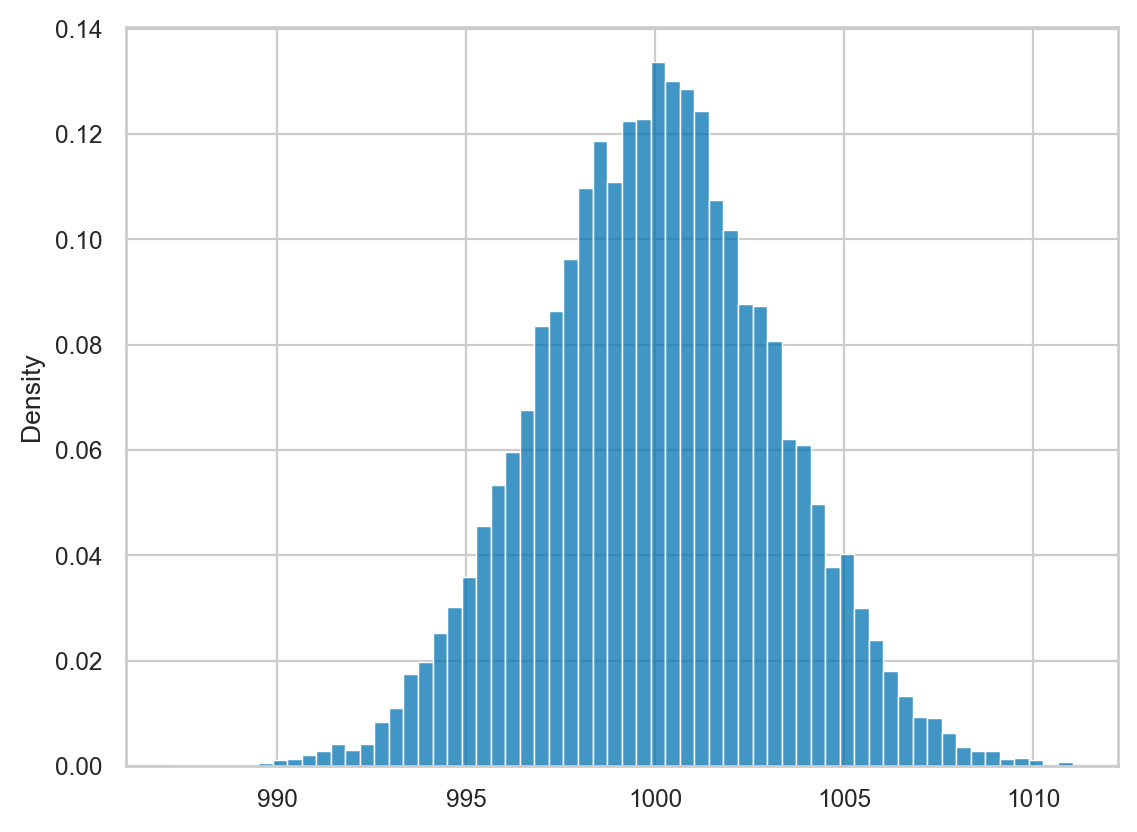

In [84]:
# Plot the histogram obtained from the n = 10 simulation
sns.histplot(xbars10, stat="density");

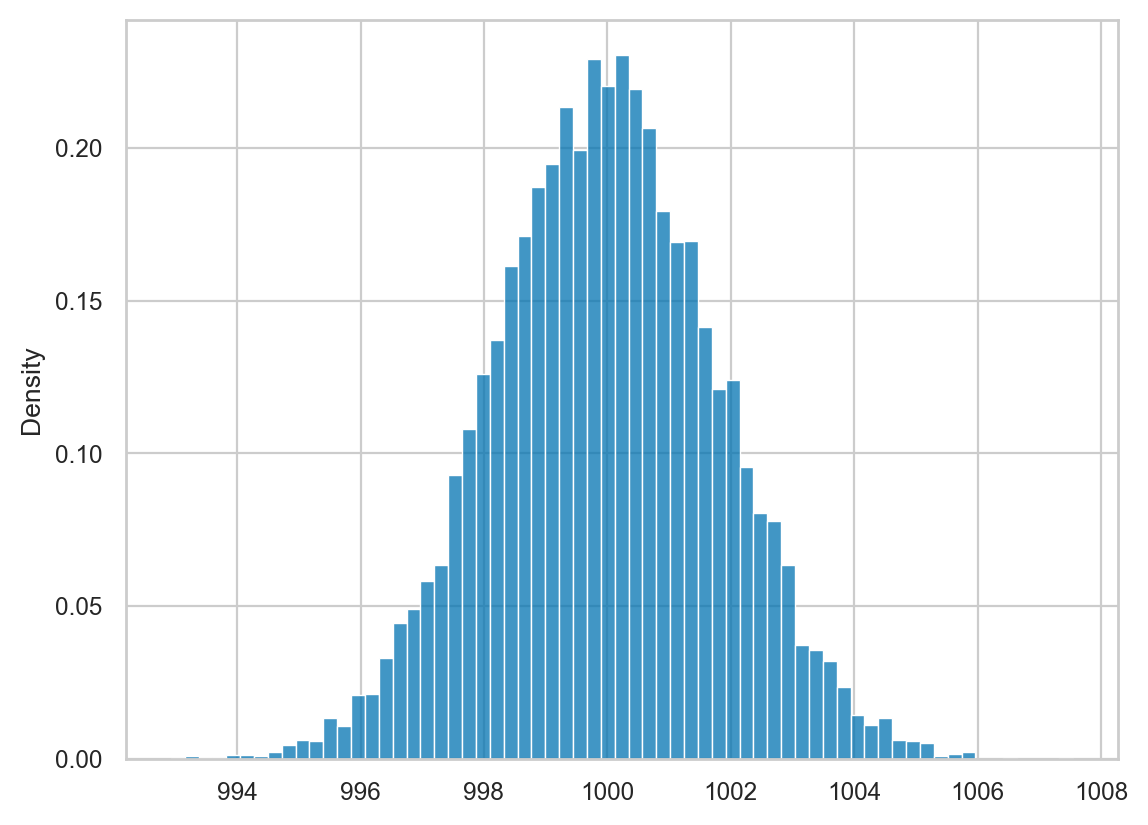

In [83]:
# Plot the histogram obtained from the n = 30 simulation
sns.histplot(xbars30, stat="density");

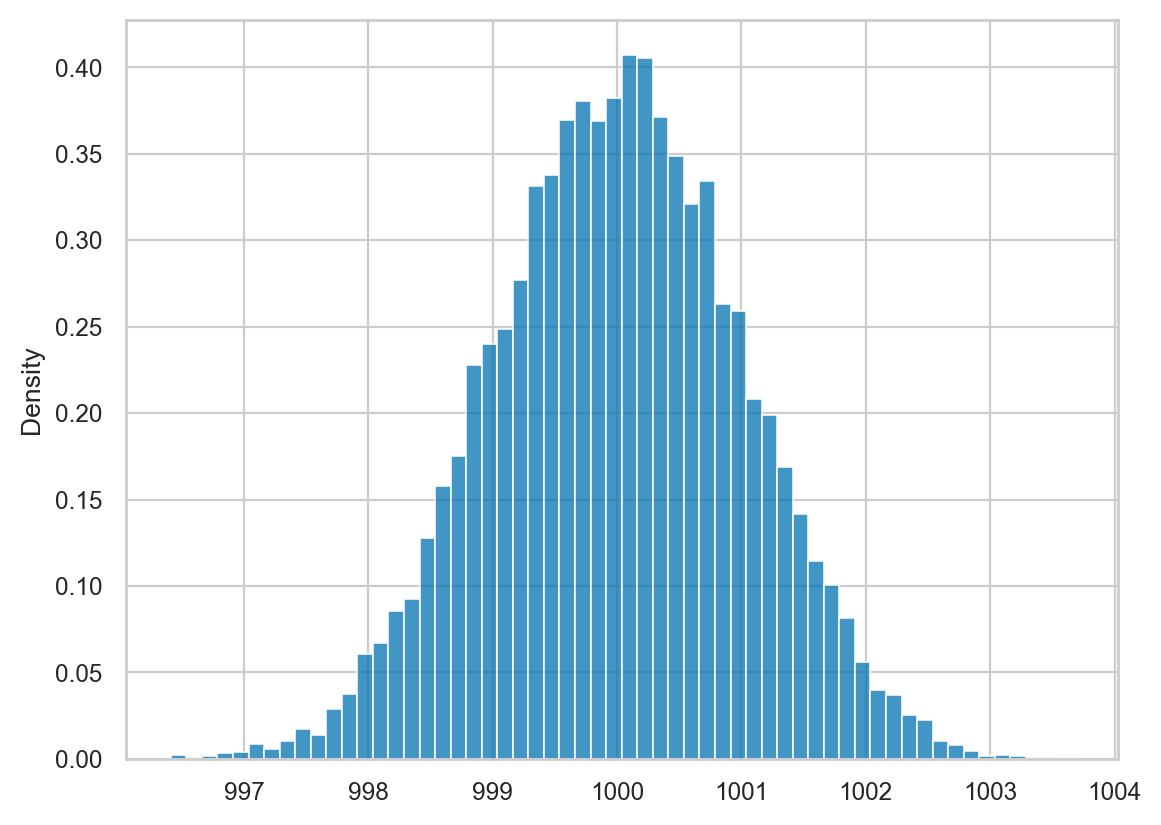

In [82]:
# Plot the histogram obtained from the n = 100 simulation
sns.histplot(xbars100, stat="density");

### E3.6

Generate sampling distribution of the mean for samples of size $n=30$ from the standard uniform model $U \sim \mathcal{U}(0,1)$ .
Plot a histogram.
Plot the prediction of the central limit theorem on the same axis.

In [31]:
# Create a computer model for the standard uniform
from scipy.stats import uniform
rvU = uniform(0,1)

(0.5, 0.28867513459481287)

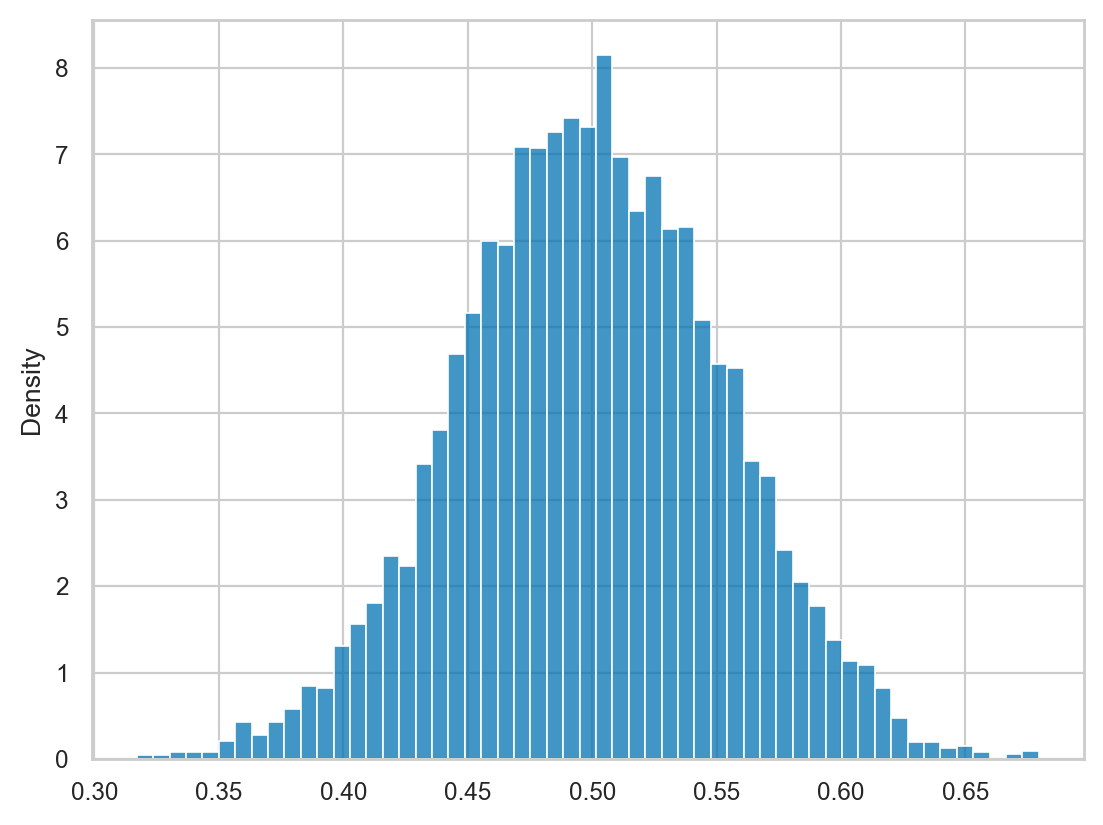

In [81]:
# Set the random seed to a particular value to get a reproducible result
np.random.seed(44)

# Simulate samples of size n = 30
ubars30 = gen_sampling_dist(rvU, estfunc=mean, n=30)

# Plot the histogram obtained from simulation
sns.histplot(ubars30, stat="density");

## Exercises 3


### E3.7

Use bootstrap estimation to obtain an approximation to the sampling distribution of the mean
from the sample of apple weights in the dataset `datasets/apples.csv` .
Based on your result,
what can you say about the unknown population mean $\mu_A$?
What is the standard error of your estimate?
State your answer as $\overline{\mathbf{a}} \pm \stderrhat{\overline{\mathbf{a}}}$ and interpret in words.

In [35]:
apples = pd.read_csv("datasets/apples.csv")
asample = apples["weight"]
apples.head(3)

,weight
0,205.0
1,182.0
2,192.0


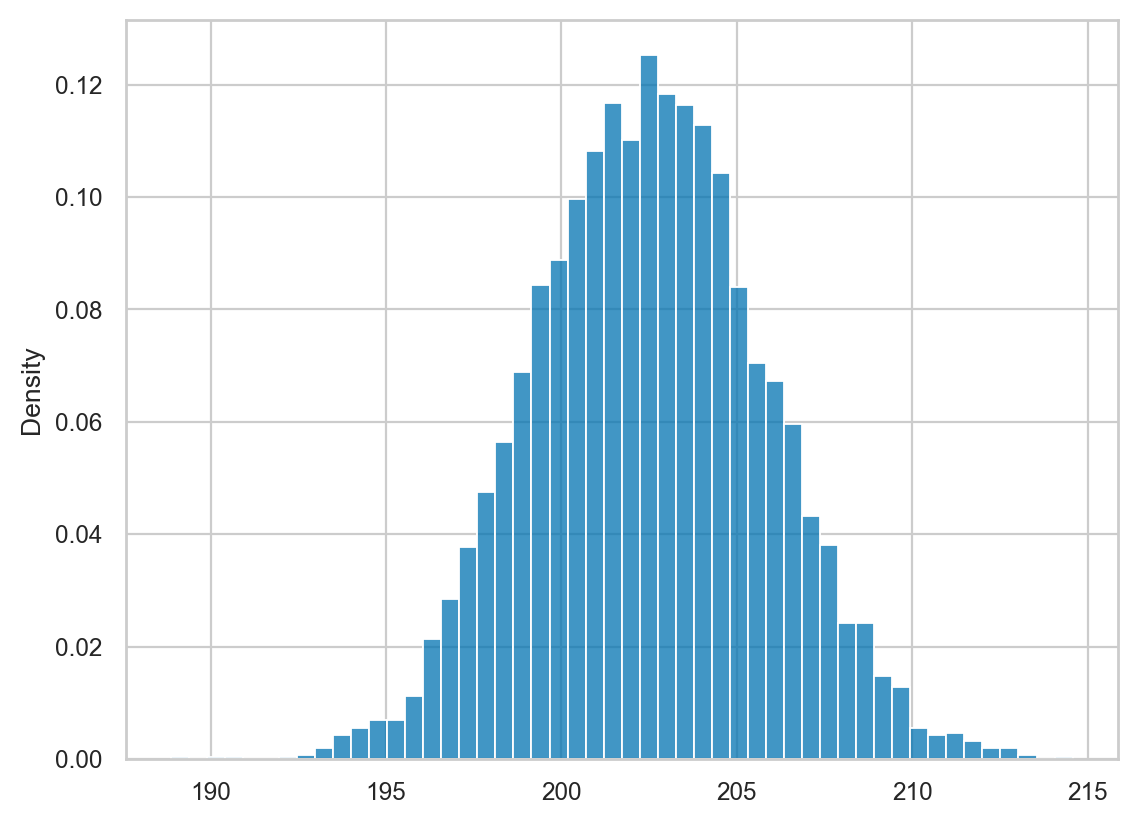

In [37]:
from ministats import gen_boot_dist

# Set the random seed to a particular value to get a reproducible result
np.random.seed(44)

# Generate the bootstrap distribution of the mean
abars_boot = gen_boot_dist(asample, estfunc=mean)

# Plot a histogram of the bootstrap distribution
sns.histplot(abars_boot, stat="density");

In [39]:
# Compute mean and standard deviation of abars_boot
np.mean(abars_boot), np.std(abars_boot)

(202.50576666666666, 3.2767382615101326)

Based on the data in `asample`,
the unknown mean of the apples population is roughly $\mu_A \approx \overline{\mathbf{a}} = 202.5$,
and the standard deviation of this estimate about the mean 
is given by the estimate standard error $\stderrhat{\overline{\mathbf{a}}} = 3.36$.

### E3.8

Compute bootstrap distribution for the sample mean from Batch 04 of the kombucha dataset,
and plot a histogram.
Do you think Batch 04 is a regular batch or an irregular batch of production?

In [40]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample04 = kombucha[kombucha["batch"]==4]["volume"]
mean(ksample04)

1003.8335

The mean of computed from the sample 04 is $\overline{\mathbf{x}}_{04} = 1003.8335$,
which is higher than expected from a regular batch ($\mu_K = 1000$).

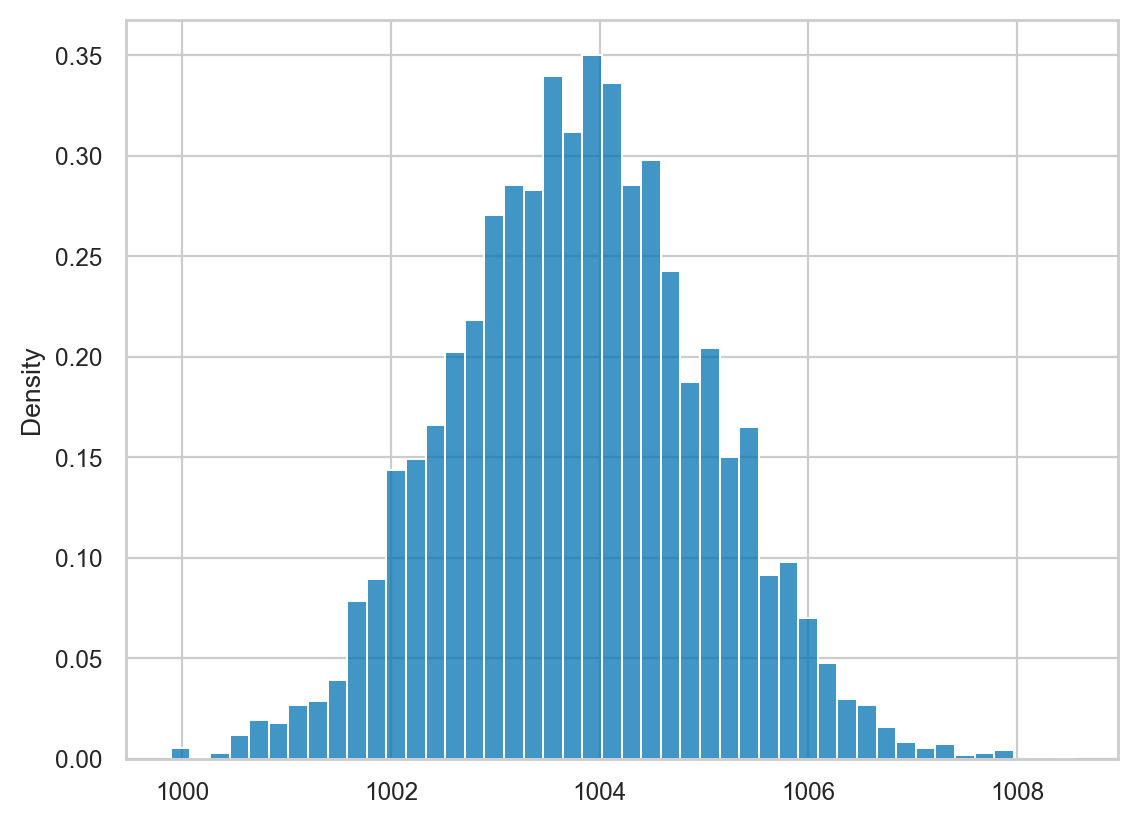

In [41]:
kbars04_boot = gen_boot_dist(ksample04, estfunc=mean)
sns.histplot(kbars04_boot, stat="density");

Even when we take into account of the possible variability
in the estimate $\overline{\mathbf{x}}_{04}$
we see that the we're still very far from the expected mean $\mu_K = 1000$.

This means the Batch 04 is likely not regular batch:
the volume in this batch is higher than expected for regular batches $\mu_K = 1000$.

## Exercises 4

### E3.9

Describe your uncertainty about the unknown population mean $\mu_A$ based on sample of apple weights from the dataset `datasets/apples.csv`:  
**a)** find an analytical formula in terms Student's $t$ -distribution,  
**b)** use bootstrap estimation,  
**c)** compare your answers from part a) and b) graphically.

In [42]:
apples = pd.read_csv("datasets/apples.csv")
asample = apples["weight"]
apples.head(3)

,weight
0,205.0
1,182.0
2,192.0


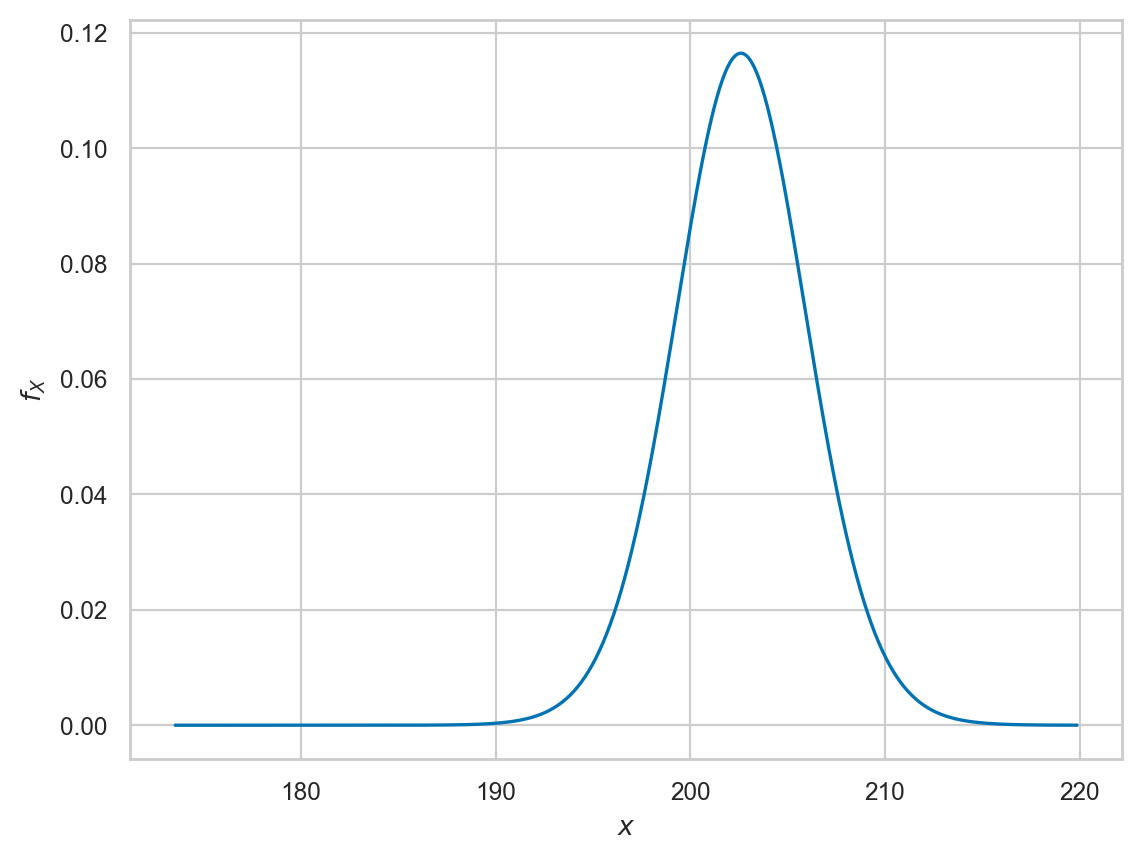

In [44]:
# a) Find the CLT approximation
from scipy.stats import t as tdist

n = asample.count()
df = n-1
loc = mean(asample)
scale = std(asample) / np.sqrt(30)
rvTAbar = tdist(df, loc=loc, scale=scale)

# Plot the pdf of the CLT approximation
ax = plot_pdf(rvTAbar)

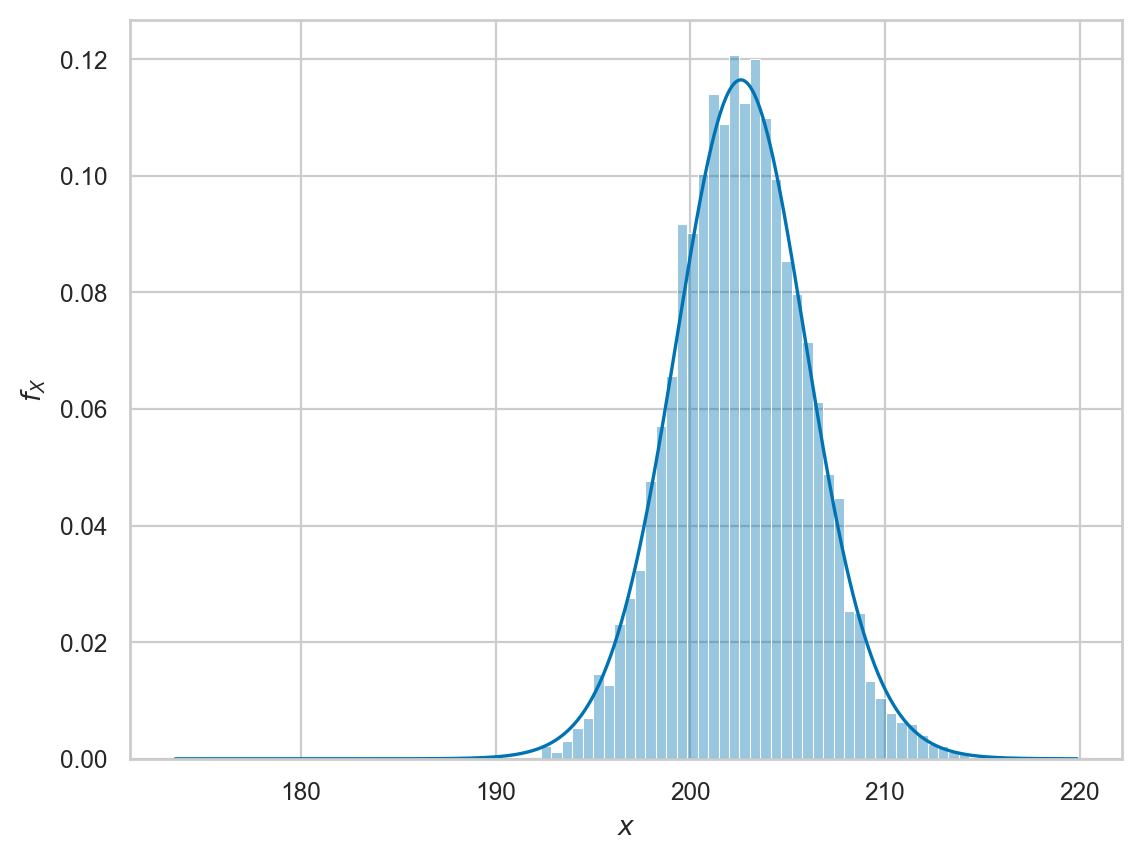

In [46]:
# b) obtain a bootstrap approximation
abars_boot = gen_boot_dist(asample, estfunc=mean)
sns.histplot(abars_boot, stat="density", ax=ax, alpha=0.4)
ax.figure

## Exercises 5

### E3.10

Under regular operations,
the kombucha volume is described by the model `rvK`  $= K \sim \mathcal{N}(1000,10)$ .  
**a)** Plot the probability density function for the sampling distribution of the variance for samples of size $n=40$ from the population $K$ .  
**b)** Compute the sample variance of Batch 08 from the kombucha dataset.  
**c)** Compare the observed value in b) to the sampling distribution in a).
Does it look like this is a regular batch or irregular batch?

In [47]:
# Define the variance estimator function
def var(sample):
    xbar = sum(sample) / len(sample)
    sumsqdevs = sum([(xi-xbar)**2 for xi in sample])
    return sumsqdevs / (len(sample)-1)

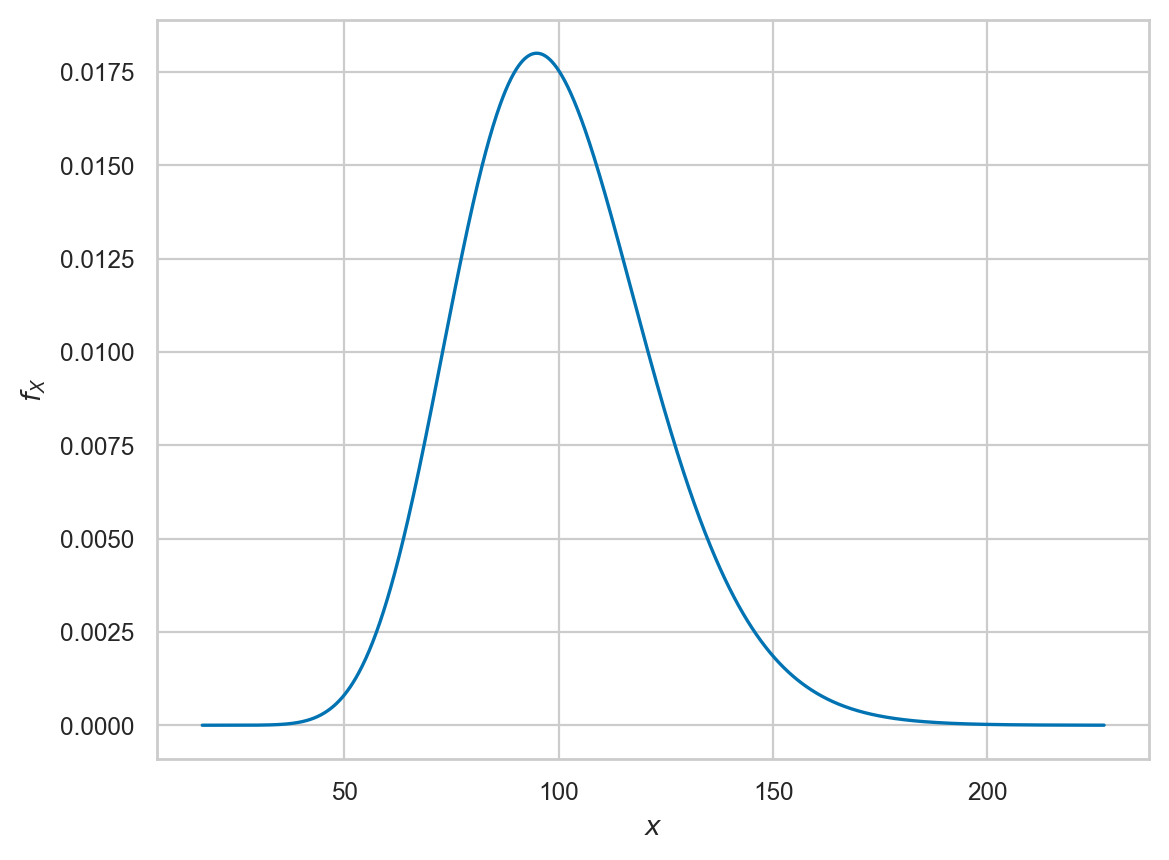

In [49]:
# a) Find the sampling distribution of the sample variance
from scipy.stats import chi2

n = 40
df = n - 1
scale = sigmaK**2 / (n-1)
rvS2 = chi2(df, loc=0, scale=scale)

# Plot the pdf of the CLT approximation
plot_pdf(rvS2);

In [51]:
# b) the sample variance of Batch 04 is
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample08 = kombucha[kombucha["batch"]==8]["volume"]
var(ksample08)

169.9979220512824

c) The observed value $s_{\mathbf{k}_{08}} = 167$ is very unlikely to occur
under the expected sampling distribution for the sample variance
for regular samples.
This suggests that Batch 08 is an irregular batch with abnormally high variance.
Better check the machine.

### E3.11

Compute the bootstrap approximation for sampling distribution of the variance
from Batch 08 of the kombucha dataset.
Plot a histogram.

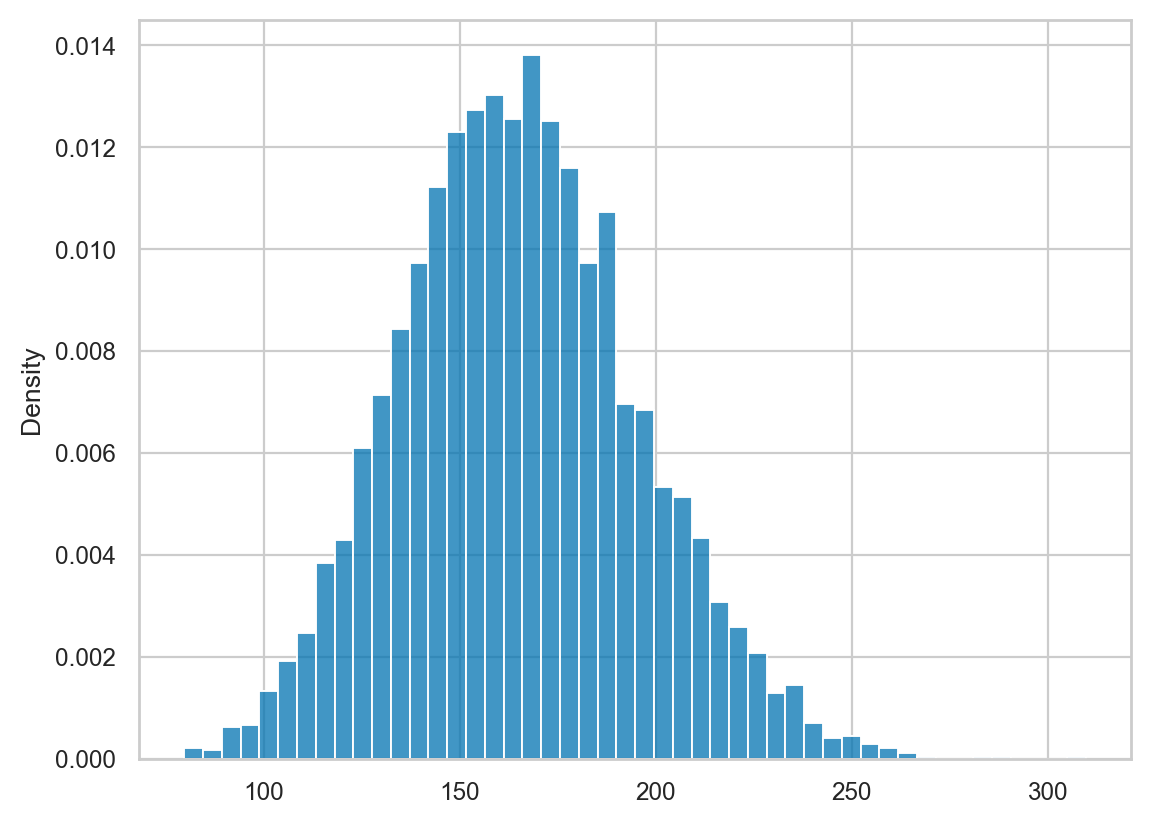

In [53]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample08 = kombucha[kombucha["batch"]==8]["volume"]

kvars08_boot = gen_boot_dist(ksample08, estfunc=var)
sns.histplot(kvars08_boot, stat="density");

The bootstrap estimates we observe are very far from the 
expected standard deviation for regular batches,
which is $\sigma_K^2 = 100$,
which tells us Batch 08 might be irregular (abnormally high variance).

## Exercises 6

### E3.12

Describe the uncertainty about the difference between means `dmeans(scoresR,scoresU)`,
where `scoresR` and `scoresU` are sleep scores of the rural and urban doctors
from the doctors dataset `datasets/doctors.csv`.  
**a)** Find an analytical formula in terms Student's $t$ -distribution.  
**b)** Use bootstrap estimation.  
**c)** Compare your answers from part a) and b) graphically.

In [54]:
import numpy as np

# Define the `dmeans` estimator function
def dmeans(xsample, ysample):
    dhat = np.mean(xsample) - np.mean(ysample)
    return dhat

In [55]:
doctors = pd.read_csv("datasets/doctors.csv")
scoresR = doctors[doctors["loc"]=="rur"]["score"]
scoresU = doctors[doctors["loc"]=="urb"]["score"]

# observed value
dscores = dmeans(scoresR, scoresU)
dscores

6.992885375494076

In [57]:
# a) analytical approximation

# obtain the sample sizes and stds of the two groups
nR = scoresR.count()
stdR = scoresR.std()
nU = scoresU.count()
stdU = scoresU.std()

# standard error of the difference between group means
seDhatscores = np.sqrt(stdU**2/nU + stdR**2/nR)
print("Estimated sample standard error", seDhatscores)

# calculate the degrees of freedom
from ministats import calcdf
df = calcdf(stdU, nU, stdR, nR)

# probability model based on Student's t-distribution
from scipy.stats import t as tdist
rvDscores = tdist(df, loc=dscores, scale=seDhatscores)

Estimated sample standard error 3.5671565854251948


In [59]:
# b) bootstrap estimate
# compute bootstrap estimates for mean in each group
meanR_boot = gen_boot_dist(scoresR, estfunc=mean)
meanU_boot = gen_boot_dist(scoresU, estfunc=mean)

# compute the difference between means of bootstrap samples
dmeans_boot = np.subtract(meanR_boot, meanU_boot)
# show first of the 5 boostrap estimate sin the list of N=10000
# dmeans_boot[0:5]

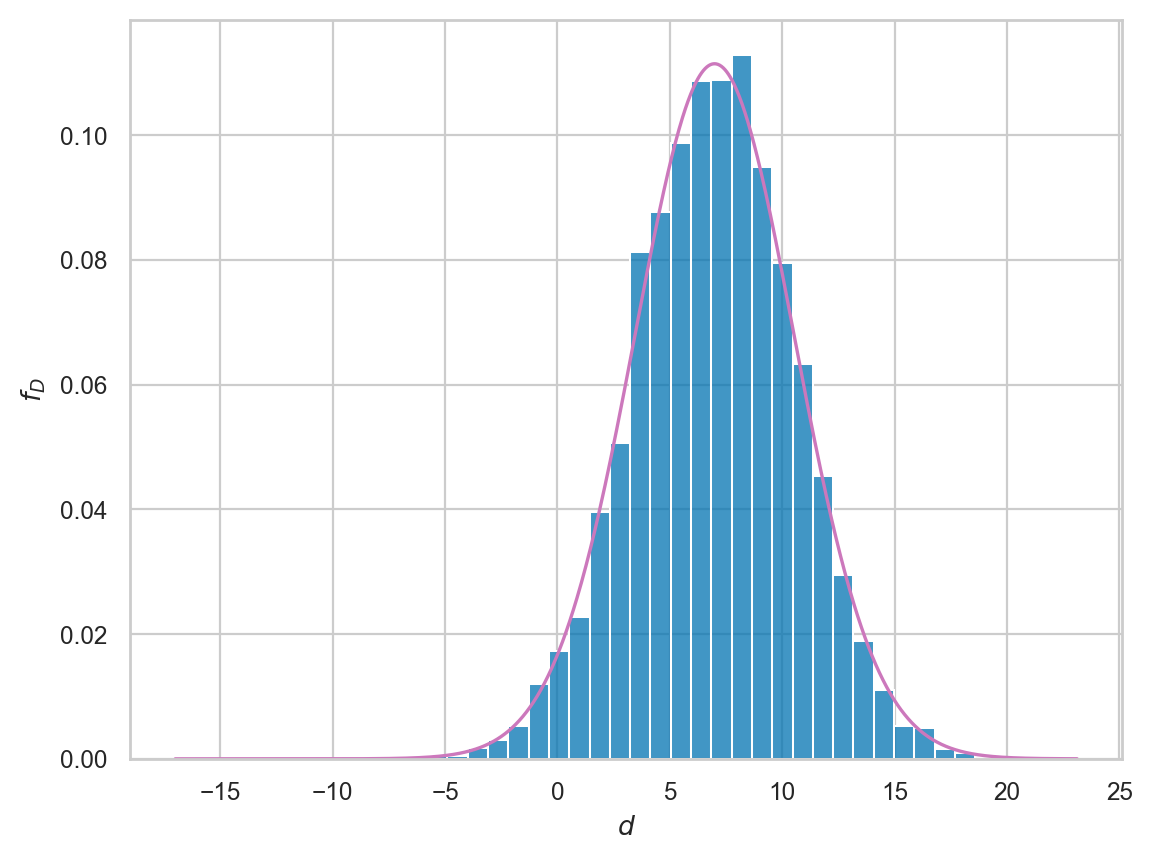

In [61]:
# c) plot the answers form a) and b)

# pdf of the analytical approximation 
ax = plot_pdf(rvDscores, rv_name="D", color="C4")

# histogtam of the bootstrap approximation
sns.histplot(dmeans_boot, ax=ax, stat="density", bins=30);

## Exercises 7


### E3.13

Generate the sampling distribution of the median for samples of size $n=30$ from the population `rvK` $= K \sim \mathcal{N}(1000,10)$ .

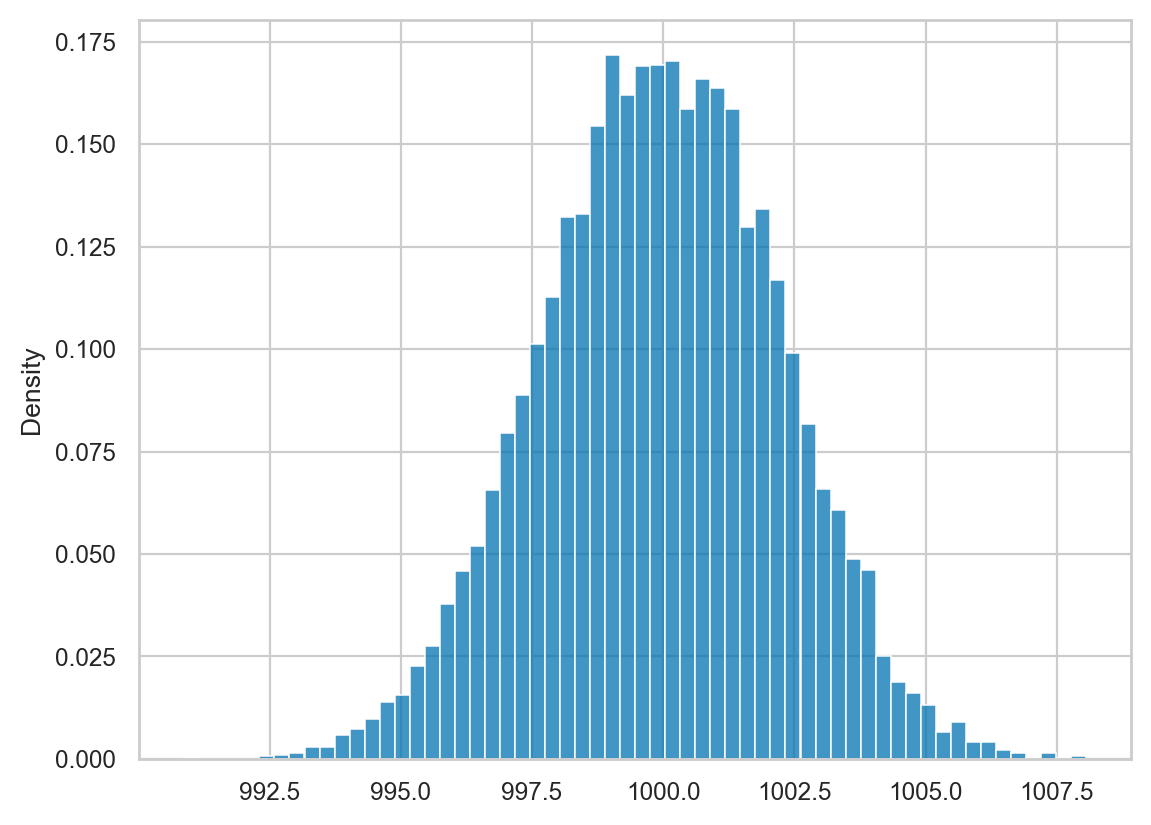

In [63]:
from scipy.stats import norm
rvK = norm(1000, 10)

# compute the sampling distribution of the median
# for samples of size n=30 from rvK
kmedians30 = gen_sampling_dist(rvK, estfunc=np.median, n=30)
sns.histplot(kmedians30, stat="density");

In [65]:
# compute se of the sampling distribution of the median 
np.std(kmedians30)

2.2558855561619473

### E3.14

Generate the sampling distribution of `P90` , the 90th percentile estimator,
from samples of size $n=30$ from `rvK`  $= K \sim \mathcal{N}(1000,10)$ .
Calculate the standard error $\stderr{\tt{P90}}$ of the estimator.

In [66]:
from scipy.stats import norm
rvK = norm(1000, 10)

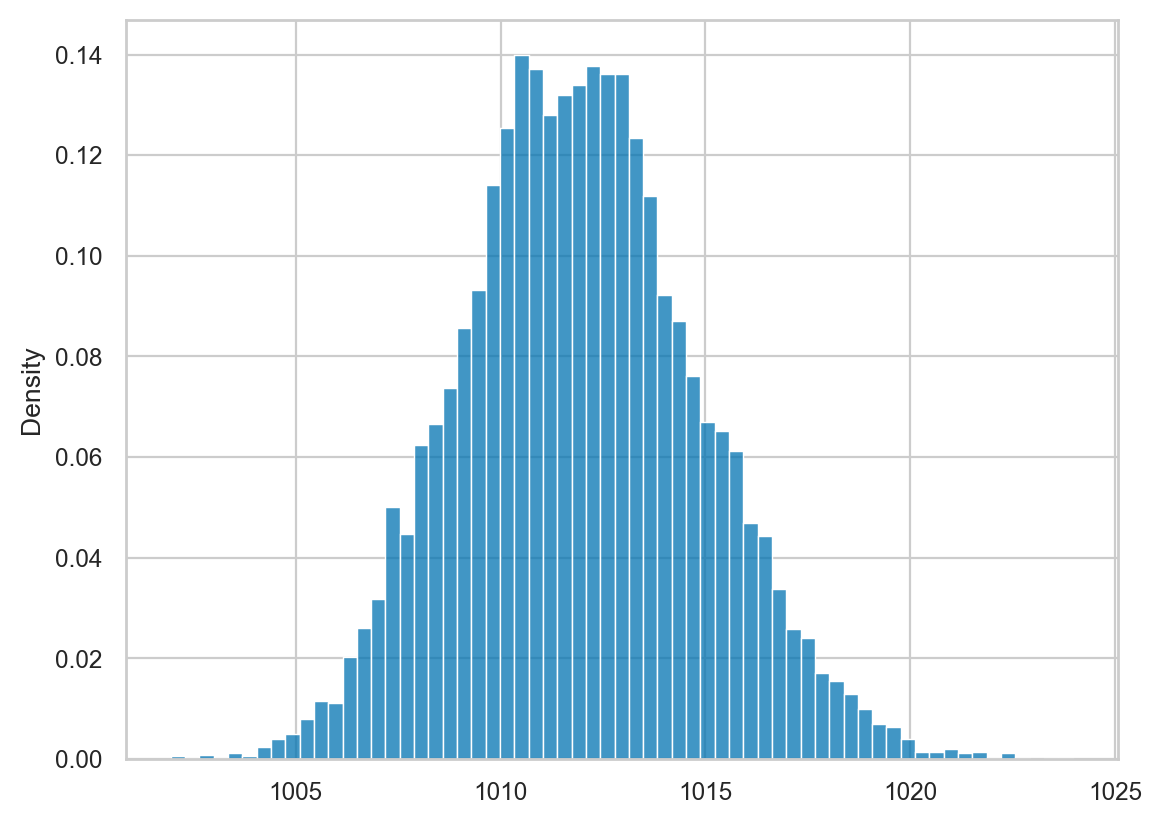

In [68]:
# 90th percentile estimator function
def p90(sample):
    return np.percentile(sample, 90)

# simulations of p90 from samples of size n=30
kp90s30 = gen_sampling_dist(rvK, estfunc=p90, n=30)
sns.histplot(kp90s30, stat="density");

In [70]:
# compute se of the kp90s30 sampling distribution
np.std(kp90s30)  # == sehat_p90

2.889847854147264

### E3.15

see text

### E3.16

Use the function `scipy.stats.boostrap` to compute the bootstrap distribution
of the variance from the sample `ksample02`.

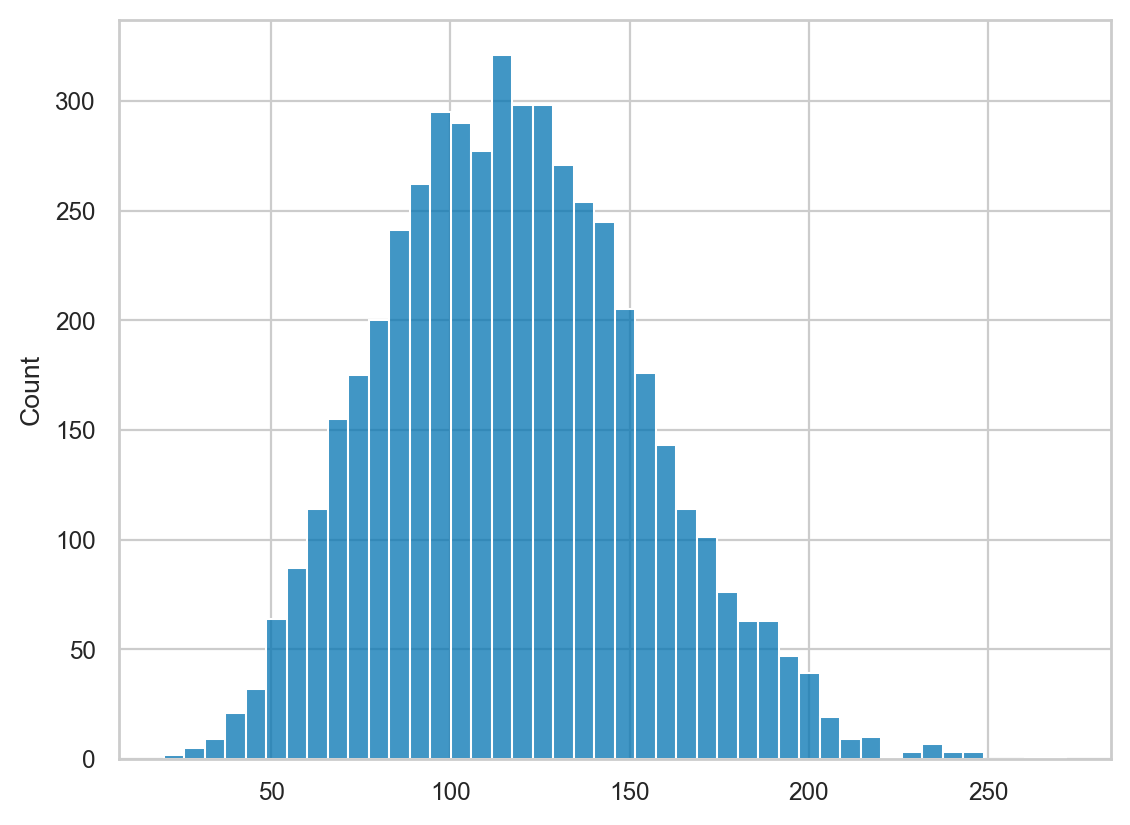

In [72]:
from scipy.stats import bootstrap

kombucha = pd.read_csv("datasets/kombucha.csv")
ksample02 = kombucha[kombucha["batch"]==2]["volume"]

# call the function bootstrap
np.random.seed(42)
res = bootstrap((ksample02,), statistic=var,
                n_resamples=5000, vectorized=False)

# plot histogram
sns.histplot(res.bootstrap_distribution);

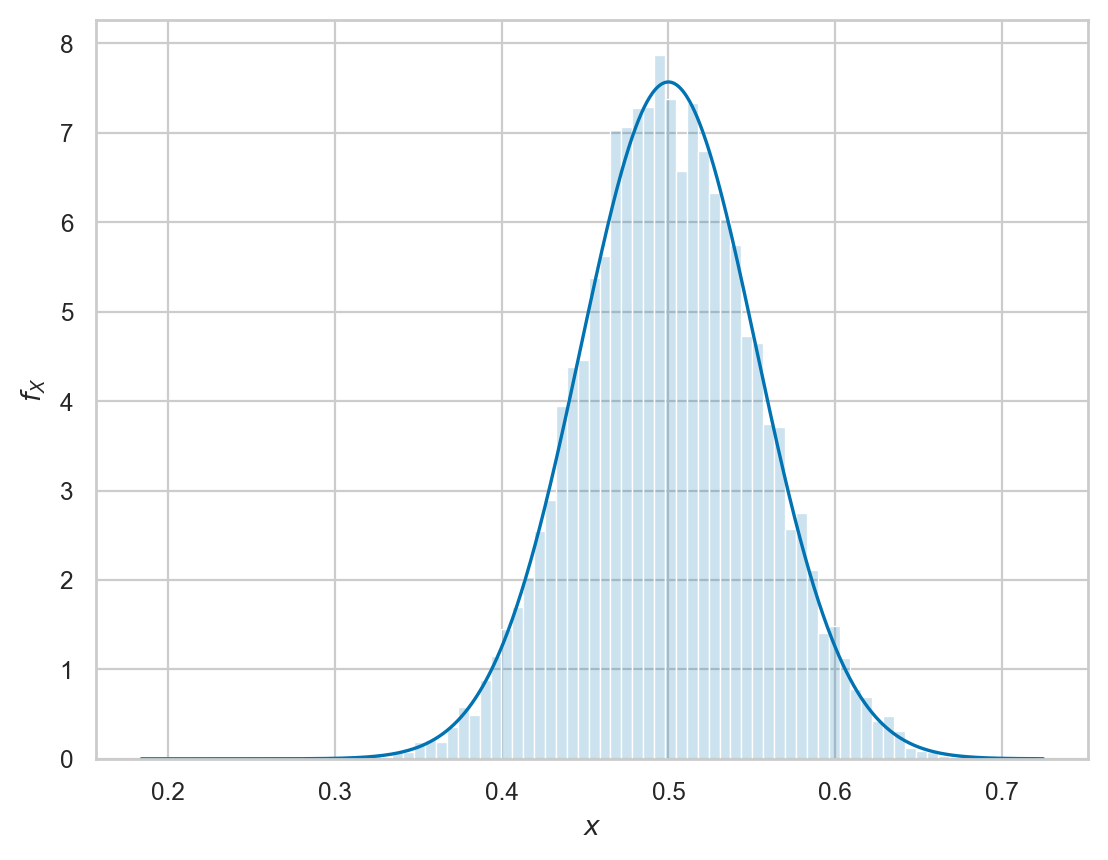

In [79]:
# Simulate samples of size n = 30
ubars30 = gen_sampling_dist(rvU, estfunc=mean, n=30)

# Plot the histogram obtained from simulation
ax = sns.histplot(ubars30, stat="density", alpha=0.2)

# Find the CLT approximation
seUbar30 = sigmaU / np.sqrt(30)
rvUbarCLT30 = norm(muU, seUbar30)

# Plot the pdf of the CLT approximation
plot_pdf(rvUbarCLT30, ax=ax);